# Intro
- Date Created: 2024.02.12
- Last Update: 2025.02.09
- Author: BL

This script takes in and preprocesses the scRNA and DBiT lung datasets, preprocesses them using scTransform, integrates them together using RPCA and returns the integrated object for CARD

Update Log:
- Added additional scRNA reference datasets
- Added additional DBiT datasets
- Removed E12lungR1 due to high diffusion in that sample
- Swapped to using Downsampled Cellreports datasets (~20k reads per cell)
- Swapped to using Ensambl IDs to avoid gene name errors (Nkx2.1 vs Nkx2-1)

In [1]:
library(Seurat)
library(Matrix)
library(ggplot2)
library(cowplot)
#library(SingleR)
library(dplyr)
library(patchwork)
library(tidyr)
library(raster)
library(grid)
library(glmGamPoi)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack



Attaching package: ‘raster’


The following object is masked from ‘package:dplyr’:

    select



Attaching package: ‘glmGamPoi’


The following object is masked from ‘package:dplyr’:

    vars


The following object is masked from ‘pac

# Setup working directory

In [2]:
dir <- "/mnt/c/Users/benja/Documents/ChanLab/Spatial_Lung/sandbox/scRNA/integration/"  
setwd(dir)

# Load and preprocess the Ctrl E12 dataset (from DevCell)

In [3]:
#Load and preprocess the ctrl E12 dataset (DevCell)
data_10X_E12R1 <- Read10X(data.dir = '/mnt/c/Users/benja/Documents//Chanlab/Spatial_Lung/raw_data/scRNA/cellranger/grcm39/E12_DevCell/filtered_feature_bc_matrix', gene.column = 1)
ctrl_12_DevCell <- CreateSeuratObject(counts=data_10X_E12R1, project='E12_DevCell', min.cells=10, min.features=200)

# Processing
ctrl_12_DevCell[["percent.mt"]] <- PercentageFeatureSet(ctrl_12_DevCell, pattern = "^mt-")
ctrl_12_DevCell[['percent.Hba']] <- PercentageFeatureSet(ctrl_12_DevCell, pattern = '^Hba')
ctrl_12_DevCell[['percent.Hbb']] <- PercentageFeatureSet(ctrl_12_DevCell, pattern = '^Hbb')

# Lower because the quality of the dataset is lower
pdf('E12_DevCell_QC.pdf')
print(length(colnames(ctrl_12_DevCell)))
VlnPlot(ctrl_12_DevCell, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
ctrl_12_DevCell <- subset(ctrl_12_DevCell, subset = nFeature_RNA > 2000 & nCount_RNA > 5000 & nCount_RNA < 80000 & percent.mt < 10 & percent.Hba < 0.5 & percent.Hbb < 0.5) # new filtering
VlnPlot(ctrl_12_DevCell, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
print(length(colnames(ctrl_12_DevCell)))
dev.off()

[1] 13438


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”


[1] 6296


pdf 
  2

# Load and preprocess the ctrl E11 dataset (not the split version)

In [4]:
# Load data
data_10X_E11R1 <- Read10X(data.dir = '/mnt/c/Users/benja/Documents/Chanlab/Spatial_Lung/raw_data/scRNA/cellranger/grcm39/E11_iScience_R1/filtered_feature_bc_matrix', gene.column = 1)
ctrl_11_R1 <- CreateSeuratObject(counts=data_10X_E11R1, project='E11_iScience_R1', min.cells=10, min.features=200)

# Processing
ctrl_11_R1[["percent.mt"]] <- PercentageFeatureSet(ctrl_11_R1, pattern = "^mt-")
ctrl_11_R1[['percent.Hba']] <- PercentageFeatureSet(ctrl_11_R1, pattern = '^Hba')
ctrl_11_R1[['percent.Hbb']] <- PercentageFeatureSet(ctrl_11_R1, pattern = '^Hbb')

# Lower because the quality of the dataset is lower
pdf('E11_iScience_R1_QC.pdf')
print(length(colnames(ctrl_11_R1)))
VlnPlot(ctrl_11_R1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
ctrl_11_R1 <- subset(ctrl_11_R1, subset = nFeature_RNA > 2000 & nCount_RNA > 5000 & nCount_RNA < 80000 & percent.mt < 10 & percent.Hba < 0.5 & percent.Hbb < 0.5) # new filtering
VlnPlot(ctrl_11_R1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
print(length(colnames(ctrl_11_R1)))
dev.off()

[1] 1482


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”


[1] 610


pdf 
  2

# Load and preprocess the ctrl E12 cellreports rep1 dataset

- This dataset and the rep2 dataset were found to be sequencing replicates of each other. Since this dataset is already sequenced very deeply, we will just keep the rep1

In [5]:
# Load data
# There is slightly more %ptmito genes, so i'm raising the cutoff abit
data_10X_E12_cellR1 <- Read10X(data.dir = '/mnt/c/Users/benja/Documents/Chanlab/Spatial_Lung/raw_data/scRNA/cellranger/grcm39/E12_CellReports_R1/filtered_feature_bc_matrix', gene.column = 1)
ctrl_12_cellR1 <- CreateSeuratObject(counts=data_10X_E12_cellR1, project='E12_CellReports_R1', min.cells=10, min.features=200)

# Processing
ctrl_12_cellR1[["percent.mt"]] <- PercentageFeatureSet(ctrl_12_cellR1, pattern = "^mt-")
ctrl_12_cellR1[['percent.Hba']] <- PercentageFeatureSet(ctrl_12_cellR1, pattern = '^Hba')
ctrl_12_cellR1[['percent.Hbb']] <- PercentageFeatureSet(ctrl_12_cellR1, pattern = '^Hbb')

pdf('E12_CellReports_rep1_QC.pdf')
VlnPlot(ctrl_12_cellR1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
ctrl_12_cellR1 <- subset(ctrl_12_cellR1, subset = nFeature_RNA > 2000 & nCount_RNA > 10000 & nCount_RNA < 80000 & percent.mt < 10 & percent.Hba < 0.5 & percent.Hbb < 0.5) # new filtering
VlnPlot(ctrl_12_cellR1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
dev.off()

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”


pdf 
  2

# Load and preprocess the ctrl E13 cellreports dataset

In [6]:
# Load data
data_10X_E13_cell <- Read10X(data.dir = '/mnt/c/Users/benja/Documents/Chanlab/Spatial_Lung/raw_data/scRNA/cellranger/grcm39/E13_CellReports/filtered_feature_bc_matrix', gene.column = 1)
ctrl_13_cell <- CreateSeuratObject(counts=data_10X_E13_cell, project='E13_CellReports', min.cells=10, min.features=200)

# Processing
ctrl_13_cell[["percent.mt"]] <- PercentageFeatureSet(ctrl_13_cell, pattern = "^mt-")
ctrl_13_cell[['percent.Hba']] <- PercentageFeatureSet(ctrl_13_cell, pattern = '^Hba')
ctrl_13_cell[['percent.Hbb']] <- PercentageFeatureSet(ctrl_13_cell, pattern = '^Hbb')

pdf('E13_CellReports_QC.pdf')
VlnPlot(ctrl_13_cell, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
ctrl_13_cell <- subset(ctrl_13_cell, subset = nFeature_RNA > 2000 & nCount_RNA > 10000 & nCount_RNA < 80000 & percent.mt < 10 & percent.Hba < 0.5 & percent.Hbb < 0.5) # new filtering
VlnPlot(ctrl_13_cell, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
dev.off()

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”


pdf 
  2

# Load and preprocess the ctrl E12 Science dataset

In [7]:
# Load the Science reference
data_10X_12_science <- Read10X(data.dir = '/mnt/c/Users/benja/Documents/Chanlab/Spatial_Lung/raw_data/scRNA/cellranger/grcm39/E12_Science/filtered_feature_bc_matrix', gene.column = 1)
ctrl_12_science <- CreateSeuratObject(counts=data_10X_12_science, project='E12_Science', min.cells=10, min.features=200)

# Processing
ctrl_12_science[["percent.mt"]] <- PercentageFeatureSet(ctrl_12_science, pattern = "^mt-")
ctrl_12_science[['percent.Hba']] <- PercentageFeatureSet(ctrl_12_science, pattern = '^Hba')
ctrl_12_science[['percent.Hbb']] <- PercentageFeatureSet(ctrl_12_science, pattern = '^Hbb')

pdf('E12_Science_QC.pdf')
VlnPlot(ctrl_12_science, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
ctrl_12_science <- subset(ctrl_12_science, subset = nFeature_RNA > 2000 & nCount_RNA > 5000 & nCount_RNA < 80000 & percent.mt < 10 & percent.Hba < 0.5 & percent.Hbb < 0.5) # new filtering
VlnPlot(ctrl_12_science, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
dev.off()

ERROR: Error in pdf("E12_Science_QC.pdf"): cannot open file 'E12_Science_QC.pdf'


# Load and preprocess the DBiT samples

In [23]:
# Load the E11 datasets
dbit_11_R1 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20230513_E11_R1_Ensembl_vM31.RDS")
dbit_11_R2 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20231120_E11_R2_Ensembl_vM31.RDS")
dbit_11_R3 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20231125_E11_R3_Ensembl_vM31.RDS")
dbit_11_R4 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20231129_E11_R4_Ensembl_vM31.RDS")
dbit_11_R5 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20240119_E11_R5_Ensembl_vM31.RDS")

# Load the E12 datasets, R1 has been removed because of diffusion error
dbit_12_R2 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20230830_E12_R2_Ensembl_vM31.RDS")
dbit_12_R3 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20230920_E12_R3_Ensembl_vM31.RDS")
dbit_12_R4 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20240101_E12_R4_Ensembl_vM31.RDS")
dbit_12_R5 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20230730_E12_R5_Ensembl_vM31.RDS")

# Load the E13 datasets
dbit_13_R1 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20231102_E13_R1_Ensembl_vM31.RDS")
dbit_13_R2 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20231103_E13_R2_Ensembl_vM31.RDS")
dbit_13_R3 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20231230_E13_R3_Ensembl_vM31.RDS")
dbit_13_R4 <- readRDS("/mnt/c/Users/benja/Documents//ChanLab/Spatial_Lung/raw_data/scRNA/raw_seurat_obj/grcm39/20231020_E13_R4_Ensembl_vM31.RDS")

# add a new orig.ident to match the previous nomenclature
dbit_11_R1$old.orig.ident <- dbit_11_R1$orig.ident
dbit_11_R1$orig.ident <- 'E11lungR1'
dbit_11_R2$old.orig.ident <- dbit_11_R2$orig.ident
dbit_11_R2$orig.ident <- 'E11lungR2'
dbit_11_R3$old.orig.ident <- dbit_11_R3$orig.ident
dbit_11_R3$orig.ident <- 'E11lungR3'
dbit_11_R4$old.orig.ident <- dbit_11_R4$orig.ident
dbit_11_R4$orig.ident <- 'E11lungR4'
dbit_11_R5$old.orig.ident <- dbit_11_R5$orig.ident
dbit_11_R5$orig.ident <- 'E11lungR5'

dbit_12_R2$old.orig.ident <- dbit_12_R2$orig.ident
dbit_12_R2$orig.ident <- 'E12lungR2'
dbit_12_R3$old.orig.ident <- dbit_12_R3$orig.ident
dbit_12_R3$orig.ident <- 'E12lungR3'
dbit_12_R4$old.orig.ident <- dbit_12_R4$orig.ident
dbit_12_R4$orig.ident <- 'E12lungR4'
dbit_12_R5$old.orig.ident <- dbit_12_R5$orig.ident
dbit_12_R5$orig.ident <- 'E12lungR5'

dbit_13_R1$old.orig.ident <- dbit_13_R1$orig.ident
dbit_13_R1$orig.ident <- 'E13lungR1'
dbit_13_R2$old.orig.ident <- dbit_13_R2$orig.ident
dbit_13_R2$orig.ident <- 'E13lungR2'
dbit_13_R3$old.orig.ident <- dbit_13_R3$orig.ident
dbit_13_R3$orig.ident <- 'E13lungR3'
dbit_13_R4$old.orig.ident <- dbit_13_R4$orig.ident
dbit_13_R4$orig.ident <- 'E13lungR4'

In [24]:
# Change the gene names to match the naming nomenclature of the scRNA datasets
rownames(dbit_11_R1) <- gsub("\\..*","",rownames(dbit_11_R1))
rownames(dbit_11_R2) <- gsub("\\..*","",rownames(dbit_11_R2))
rownames(dbit_11_R3) <- gsub("\\..*","",rownames(dbit_11_R3))
rownames(dbit_11_R4) <- gsub("\\..*","",rownames(dbit_11_R4))
rownames(dbit_11_R5) <- gsub("\\..*","",rownames(dbit_11_R5))

rownames(dbit_12_R2) <- gsub("\\..*","",rownames(dbit_12_R2))
rownames(dbit_12_R3) <- gsub("\\..*","",rownames(dbit_12_R3))
rownames(dbit_12_R4) <- gsub("\\..*","",rownames(dbit_12_R4))
rownames(dbit_12_R5) <- gsub("\\..*","",rownames(dbit_12_R5))

rownames(dbit_13_R1) <- gsub("\\..*","",rownames(dbit_13_R1))
rownames(dbit_13_R2) <- gsub("\\..*","",rownames(dbit_13_R2))
rownames(dbit_13_R3) <- gsub("\\..*","",rownames(dbit_13_R3))
rownames(dbit_13_R4) <- gsub("\\..*","",rownames(dbit_13_R4))

In [25]:
pdf('dbit_QC.pdf')

# dbit 11
dbit_11_R1[['percent.mt']] <- PercentageFeatureSet(dbit_11_R1, pattern = '^mt-')
dbit_11_R1[['percent.Hba']] <- PercentageFeatureSet(dbit_11_R1, pattern = '^Hba')
dbit_11_R1[['percent.Hbb']] <- PercentageFeatureSet(dbit_11_R1, pattern = '^Hbb')
VlnPlot(dbit_11_R1, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")
dbit_11 <- subset(dbit_11_R1, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_11_R1, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")

# dbit 11 R2
dbit_11_R2[['percent.mt']] <- PercentageFeatureSet(dbit_11_R2, pattern = '^mt-')
dbit_11_R2[['percent.Hba']] <- PercentageFeatureSet(dbit_11_R2, pattern = '^Hba')
dbit_11_R2[['percent.Hbb']] <- PercentageFeatureSet(dbit_11_R2, pattern = '^Hbb')
VlnPlot(dbit_11_R2, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")
dbit_11_R2 <- subset(dbit_11_R2, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_11_R2, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")

# dbit 11 R3
dbit_11_R3[['percent.mt']] <- PercentageFeatureSet(dbit_11_R3, pattern = '^mt-')
dbit_11_R3[['percent.Hba']] <- PercentageFeatureSet(dbit_11_R3, pattern = '^Hba')
dbit_11_R3[['percent.Hbb']] <- PercentageFeatureSet(dbit_11_R3, pattern = '^Hbb')
VlnPlot(dbit_11_R3, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")
dbit_11_R3 <- subset(dbit_11_R3, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_11_R3, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")

# dbit 11 R4
dbit_11_R4[['percent.mt']] <- PercentageFeatureSet(dbit_11_R4, pattern = '^mt-')
dbit_11_R4[['percent.Hba']] <- PercentageFeatureSet(dbit_11_R4, pattern = '^Hba')
dbit_11_R4[['percent.Hbb']] <- PercentageFeatureSet(dbit_11_R4, pattern = '^Hbb')
VlnPlot(dbit_11_R4, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")
dbit_11_R4 <- subset(dbit_11_R4, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_11_R4, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")

# dbit 11 R5
dbit_11_R5[['percent.mt']] <- PercentageFeatureSet(dbit_11_R5, pattern = '^mt-')
dbit_11_R5[['percent.Hba']] <- PercentageFeatureSet(dbit_11_R5, pattern = '^Hba')
dbit_11_R5[['percent.Hbb']] <- PercentageFeatureSet(dbit_11_R5, pattern = '^Hbb')
VlnPlot(dbit_11_R5, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")
dbit_11_R5 <- subset(dbit_11_R5, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_11_R5, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_11")

#dbit 12 R2 - 300 filter because lower umi capture in this expr
dbit_12_R2[['percent.mt']] <- PercentageFeatureSet(dbit_12_R2, pattern = '^mt-')
dbit_12_R2[['percent.Hba']] <- PercentageFeatureSet(dbit_12_R2, pattern = '^Hba')
dbit_12_R2[['percent.Hbb']] <- PercentageFeatureSet(dbit_12_R2, pattern = '^Hbb')
VlnPlot(dbit_12_R2, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R2")
dbit_12_R2 <- subset(dbit_12_R2, subset = nFeature_RNA > 200 & nCount_RNA > 300)
VlnPlot(dbit_12_R2, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R2")

#dbit 12 R3 - 300 filter because lower umi capture in this expr
dbit_12_R3[['percent.mt']] <- PercentageFeatureSet(dbit_12_R3, pattern = '^mt-')
dbit_12_R3[['percent.Hba']] <- PercentageFeatureSet(dbit_12_R3, pattern = '^Hba')
dbit_12_R3[['percent.Hbb']] <- PercentageFeatureSet(dbit_12_R3, pattern = '^Hbb')
VlnPlot(dbit_12_R3, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R3")
dbit_12_R3 <- subset(dbit_12_R3, subset = nFeature_RNA > 200 & nCount_RNA > 300)
VlnPlot(dbit_12_R3, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R3")

#dbit 12 R4
dbit_12_R4[['percent.mt']] <- PercentageFeatureSet(dbit_12_R4, pattern = '^mt-')
dbit_12_R4[['percent.Hba']] <- PercentageFeatureSet(dbit_12_R4, pattern = '^Hba')
dbit_12_R4[['percent.Hbb']] <- PercentageFeatureSet(dbit_12_R4, pattern = '^Hbb')
VlnPlot(dbit_12_R4, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R4")
dbit_12_R4 <- subset(dbit_12_R4, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_12_R4, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R4")

#dbit 12 R5
dbit_12_R5[['percent.mt']] <- PercentageFeatureSet(dbit_12_R5, pattern = '^mt-')
dbit_12_R5[['percent.Hba']] <- PercentageFeatureSet(dbit_12_R5, pattern = '^Hba')
dbit_12_R5[['percent.Hbb']] <- PercentageFeatureSet(dbit_12_R5, pattern = '^Hbb')
VlnPlot(dbit_12_R5, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R5")
dbit_12_R5 <- subset(dbit_12_R5, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_12_R5, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_12_R5")

#dbit 13 R1
dbit_13_R1[['percent.mt']] <- PercentageFeatureSet(dbit_13_R1, pattern = '^mt-')
dbit_13_R1[['percent.Hba']] <- PercentageFeatureSet(dbit_13_R1, pattern = '^Hba')
dbit_13_R1[['percent.Hbb']] <- PercentageFeatureSet(dbit_13_R1, pattern = '^Hbb')
VlnPlot(dbit_13_R1, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R1")
dbit_13_R1 <- subset(dbit_13_R1, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_13_R1, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R1")

#dbit 13 R2
dbit_13_R2[['percent.mt']] <- PercentageFeatureSet(dbit_13_R2, pattern = '^mt-')
dbit_13_R2[['percent.Hba']] <- PercentageFeatureSet(dbit_13_R2, pattern = '^Hba')
dbit_13_R2[['percent.Hbb']] <- PercentageFeatureSet(dbit_13_R2, pattern = '^Hbb')
VlnPlot(dbit_13_R2, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R2")
dbit_13_R2 <- subset(dbit_13_R2, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_13_R2, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R2")

#dbit 13 R3
dbit_13_R3[['percent.mt']] <- PercentageFeatureSet(dbit_13_R3, pattern = '^mt-')
dbit_13_R3[['percent.Hba']] <- PercentageFeatureSet(dbit_13_R3, pattern = '^Hba')
dbit_13_R3[['percent.Hbb']] <- PercentageFeatureSet(dbit_13_R3, pattern = '^Hbb')
VlnPlot(dbit_13_R3, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R3")
dbit_13_R3 <- subset(dbit_13_R3, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_13_R3, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R3")

#dbit 13 R4
dbit_13_R4[['percent.mt']] <- PercentageFeatureSet(dbit_13_R4, pattern = '^mt-')
dbit_13_R4[['percent.Hba']] <- PercentageFeatureSet(dbit_13_R4, pattern = '^Hba')
dbit_13_R4[['percent.Hbb']] <- PercentageFeatureSet(dbit_13_R4, pattern = '^Hbb')
VlnPlot(dbit_13_R4, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R3")
dbit_13_R4 <- subset(dbit_13_R4, subset = nFeature_RNA > 200 & nCount_RNA > 500)
VlnPlot(dbit_13_R4, features = c("nFeature_RNA", "nCount_RNA", 'percent.mt', 'percent.Hba', 'percent.Hbb'), group.by = 'orig.ident') + ggtitle("dbit_13_R3")
dev.off()

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.Hba.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.Hbb.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.Hba.”
Warning message in SingleExIPlot(type

pdf 
  2

# Merge and integrate the objects together
- After testing, I found that SCTv2 and RPCA integration work well for this dataset

In [26]:
# we are removing the dbit_12_R1 replicate because it shows abnormally high diffusion and the E12_CellReports_R2 because it is the same as the R1
integrated <- merge(ctrl_12_DevCell, y = c(dbit_11_R1, dbit_11_R2, dbit_11_R3, dbit_11_R4, dbit_11_R5, dbit_12_R2, dbit_12_R3, dbit_12_R4, dbit_12_R5, dbit_13_R1, dbit_13_R2, dbit_13_R3, dbit_13_R4, ctrl_11_R1, ctrl_12_science, ctrl_12_cellR1, ctrl_13_cell), project = "dbitLung")

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


In [19]:
options(future.globals.maxSize= 40891289600)

In [27]:
integrated <- SCTransform(integrated, vst.flavor = 'v2', seed.use = 1500)

Running SCTransform on assay: RNA

Running SCTransform on layer: counts.1

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Variance stabilizing transformation of count matrix of size 19677 by 6296

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells

Found 98 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19677 genes

Computing corrected count matrix for 19677 genes

Calculating gene attributes

Wall clock passed: Time difference of 33.72057 secs

Determine variable features

Centering data matrix

Getting residuals for block 1(of 2) for 1 dataset

Getting residuals for block 2(of 2) for 1 dataset

Centering data matrix

Finished calculating residuals for 1

Running SCTransform on layer: counts.2

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Variance stabilizing transformation of count m

In [26]:
integrated <- RunPCA(integrated)

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 135 features requested have not been scaled (running reduction without them): ENSMUSG00000098973, ENSMUSG00000018830, ENSMUSG00000059430, ENSMUSG00000026712, ENSMUSG00000068614, ENSMUSG00000029373, ENSMUSG00000036905, ENSMUSG00000094686, ENSMUSG00000015852, ENSMUSG00000020120, ENSMUSG00000027500, ENSMUSG00000039109, ENSMUSG00000030787, ENSMUSG00000001349, ENSMUSG00000027750, ENSMUSG00000066113, ENSMUSG00000029675, ENSMUSG00000024747, ENSMUSG00000001911, ENSMUSG00000044258, ENSMUSG00000032419, ENSMUSG00000022055, ENSMUSG00000031765, ENSMUSG00000034664, ENSMUSG00000052336, ENSMUSG00000023078, ENSMUSG00000022097, ENSMUSG00000001930, ENSMUSG00000036446, ENSMUSG00000112571, ENSMUSG00000042757, ENSMUSG00000074207, ENSMUSG00000007655, ENSMUSG00000021974, ENSMUSG00000024907, ENSMUSG00000063873, ENSMUSG00000005148, ENSMUSG00000084399, ENSMUSG00000050234, ENSMUSG00000024421, ENSMUSG00000001029, ENS

In [29]:
# Integrate the layers using the SCT normalization and RPCA settings
# Setting the ref datasets as 'reference' gives them priority in establishing the integration
integrated <- IntegrateLayers(object = integrated, method = RPCAIntegration, normalization = 'SCT',
                              reference = c(1, 15, 16, 17, 18),
                              verbose = F)

In [6]:
integrated <- readRDS("/mnt/c/Users/benja/Documents/Chanlab/Spatial_Lung/raw_data/scRNA/integrated/Lung_dbit_srf_CellReports_Science_integrated.RDS")


In [28]:
integrated <- FindNeighbors(integrated, reduction = "integrated.dr", dims = 1:12)
integrated <- FindClusters(integrated, resolution = 0.6)
integrated <- RunUMAP(integrated, dims = 1:12, reduction = 'integrated.dr', seed.use = 1500)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 38340
Number of edges: 1226028

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8889
Number of communities: 17
Elapsed time: 7 seconds


15:47:18 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

15:47:18 Read 38340 rows and found 12 numeric columns

15:47:18 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

15:47:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:47:23 Writing NN index file to temp file /tmp/RtmpVC8Sva/filea3b2a31fb10

15:47:23 Searching Annoy index using 1 thread, search_k = 3000

15:47:36 Annoy recall = 100%

15:47:37 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:47:38 Initializing from normalized Laplacian + n

In [8]:
pdf('Lung_integrated_QC.pdf')
DimPlot(integrated, reduction = "umap",group.by = "seurat_clusters", label = TRUE)
ElbowPlot(integrated)
DimPlot(integrated, reduction = "umap",group.by = "tech", order =c("scRNA-seq","DBiT-seq") , cols = c("lightblue","red", 'gray'))
DimPlot(integrated, reduction = "umap",group.by = "orig.ident")
features1 = c('ENSMUSG00000001496', 'ENSMUSG00000000567') # Nkx2-1, Sox9
features2 = c('ENSMUSG00000026586', 'ENSMUSG00000029838') # Prrx1, Ptn
features3 = c('ENSMUSG00000010797', 'ENSMUSG00000022836') # Wnt2, Mylk
FeaturePlot(integrated, features = features1) + ggtitle('Nkx2-1, Sox9')
FeaturePlot(integrated, features = features2) + ggtitle('Prrx1, Ptn')
FeaturePlot(integrated, features = features3) + ggtitle('Wnt2, Mylk')

test_ctrl_11R1 <- subset(x = integrated, subset = orig.ident == "E11_iScience_R1")
test_ctrl_12 <- subset(x = integrated, subset = orig.ident == 'E12_DevCell')
test_ctrl_12_cellR1 <- subset(x = integrated, subset = orig.ident == 'E12_CellReports_R1')
test_ctrl_12_science <- subset(x = integrated, subset = orig.ident == 'E12_Science')
test_ctrl_13_cell <- subset(x = integrated, subset = orig.ident == 'E13_CellReports')
test_dbit <- subset(x = integrated, subset = tech == 'DBiT_seq')

DimPlot(test_ctrl_11R1, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E11_iScience_R1')
DimPlot(test_ctrl_12, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12ctrl') 
DimPlot(test_ctrl_12_cellR1, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12CellReports_R1') 
DimPlot(test_ctrl_12_science, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12Science') 
DimPlot(test_ctrl_13_cell, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E13CellReports') 

DimPlot(test_dbit, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('All dbit') 
DimPlot(test_dbit, reduction = "umap",group.by = "orig.ident", label = TRUE) + ggtitle('All dbit') 
dev.off()


Warning message:
“Removing 23198 cells missing data for vars requested”


pdf 
  2

In [16]:
# Save Robj if needed
saveRDS(integrated, file = "Lung_dbit_srf_CellReports_Science_integrated.RDS")

In [17]:
# Save the objects to move to scanpy
DefaultAssay(integrated) <- 'RNA'
integrated <- JoinLayers(integrated)

genes <- rownames(integrated)
SCT_genes <- rownames(integrated@assays$SCT@meta.features)
cells <- colnames(integrated)
raw_mtx <- integrated@assays$RNA@layers$counts
SCT_mtx <- integrated@assays$SCT@counts

Matrix::writeMM(SCT_mtx, 'Lung_Integrated_SCT_counts.mtx')
Matrix::writeMM(raw_mtx, 'Lung_Integrated_raw_counts.mtx')
write.csv(genes, 'Lung_Integrated_raw_counts_genes.csv')
write.csv(SCT_genes, 'Lung_Integrated_raw_counts_SCT_genes.csv')
write.csv(cells, 'Lung_Integrated_raw_counts_cells.csv')
write.csv(integrated@meta.data, 'Lung_Integrated_metadata.csv')
write.csv(integrated@reductions$umap@cell.embeddings, 'Lung_Integrated_umap.csv')

NULL

NULL

# Subcluster the Epithelial Cells

In [21]:
integrated <- readRDS("Lung_dbit_srf_CellReports_Science_integrated.RDS")
Idents(integrated) <- integrated$seurat_clusters
epithelial = subset(integrated, idents = c("1", "5"))
epithelial$inte_seurat_clusters = epithelial$seurat_clusters

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 149 features requested have not been scaled (running reduction without them): Hbb.y, Hba.a1, Hba.a2, Hba.x, Hbb.bh1, Hbb.bt, Myh11, Hbb.bs, Actg2, Pf4, Mrc1, C1qb, Actc1, Slc4a1, Ccl21a, F13a1, Plek, Stmn2, Lyve1, Cnn1, Aldh1a7, Adamtsl1, Eln, Nfix, Postn, Tbx18, Nefl, Ctla2a, Cx3cr1, Itga2b, Sftpc, Lum, Mt1, Cxcl13, Tmem108, Adh1, Cav1, Fgf9, Vwf, Slc24a3, Gal, Gja4, X2700049A03Rik, Lama3, Col6a3, Icam2, Ppp2r2b, Nkx6.1, Klf5, Ryr3, Thsd7a, Fbln5, Plac9, X2310009B15Rik, Fam162b, Nkx2.1, S100a6, Nrg1, X1810037I17Rik, Adamts5, Phox2b, Tek, Trf, Pappa, Rspo3, Mmrn1, Abi3bp, Angpt1, Arhgap20, X2210016L21Rik, Egr1, Cavin2, Myl4, Col9a3, Dhx34, Tnik, Thbs2, Smpx, Eml5, Pawr, Adgrg6, Cftr, Col12a1, Fst, Ptpre, ENSMUSG00000038729, Egfl6, X2610318N02Rik, Pdlim5, Fcgrt, Dnah1, Ppfia2, Rasgrp2, Ppargc1a, Rgs5, Irag1, X2210016F16Rik, X1700025G04Rik, Inpp4b, Itpr2, Ifi27, Fam13a, Ogn, Itgb8, Adamts19

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5894
Number of edges: 198779

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8487
Number of communities: 6
Elapsed time: 0 seconds


20:12:39 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

20:12:39 Read 5894 rows and found 13 numeric columns

20:12:39 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

20:12:39 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:12:40 Writing NN index file to temp file /tmp/RtmpAad2BK/file1e84d6fabf3

20:12:40 Searching Annoy index using 1 thread, search_k = 3000

20:12:42 Annoy recall = 100%

20:12:42 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

20:12:43 Initializing from normalized Laplacian + no

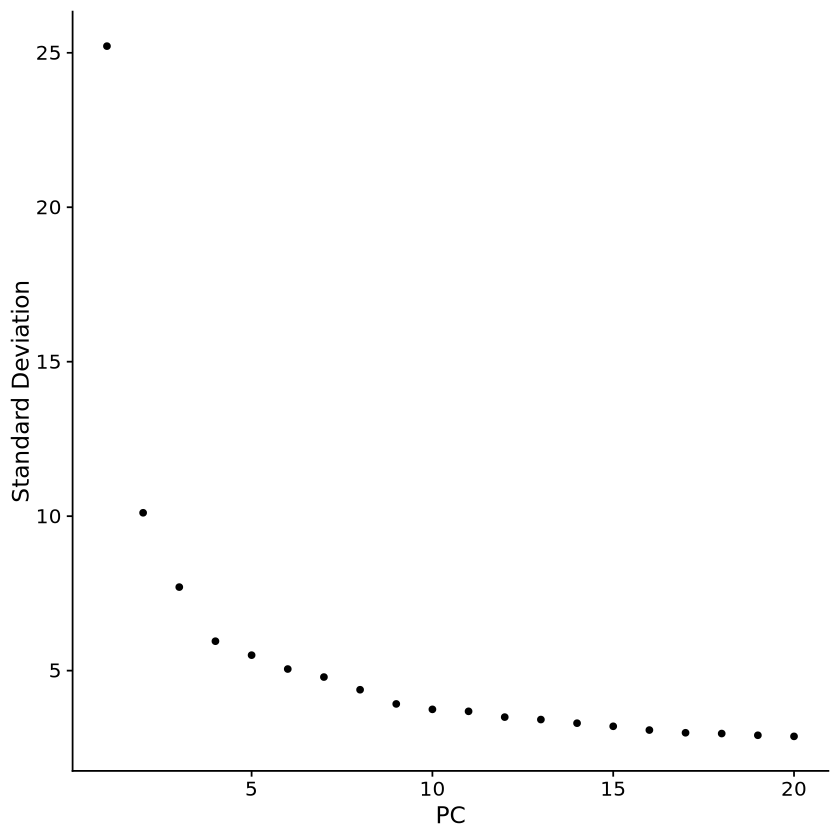

In [37]:
epithelial <- RunPCA(epithelial)
ElbowPlot(epithelial)
epithelial <- FindNeighbors(epithelial, reduction = "integrated.dr", dims = 1:13)
epithelial <- FindClusters(epithelial, resolution = 0.4)
epithelial <- RunUMAP(epithelial, dims = 1:13, reduction = 'integrated.dr')

In [ ]:
df <- data.frame(matrix(0, ncol=100, dimnames=list(NULL, paste0('neighbor',1:100))))
for (x in colnames(epithelial)) {
  df[nrow(df) + 1,] = TopNeighbors(epithelial[['SCT.nn']], cell = x, 100)
}
write.csv(df, 'epithelial_subcluster_neighbors_100.csv')
write.csv(colnames(epithelial), 'epithelial_subcluster_cellorder_100.csv')

In [38]:
pdf('integrated_epithelial_subcluster_QC.pdf')
DimPlot(epithelial, reduction = "umap",group.by = "tech", order =c("scRNA-seq","DBiT-seq") , cols = c("lightblue","red"))
DimPlot(epithelial, reduction = "umap",group.by = "orig.ident")
DimPlot(epithelial, reduction = "umap",group.by = "seurat_clusters", label = TRUE)
DimPlot(epithelial, reduction = "umap",group.by = "inte_seurat_clusters", label = TRUE)
features1 = c('Epcam', 'Wnt7b', 'Etv5', 'Id2', 'Sox2', 'Sox9', 'Sftpc', 'Icam1', 'Nkx2.1')
FeaturePlot(epithelial, features = features1)

test_ctrl_11R1 <- subset(x = epithelial, subset = orig.ident == "E11_iScience_R1")
#test_ctrl_11R2 <- subset(x = epithelial, subset = orig.ident == "E11_iScience_R2")
test_ctrl_12 <- subset(x = epithelial, subset = orig.ident == 'E12_DevCell')
test_ctrl_12_cellR1 <- subset(x = epithelial, subset = orig.ident == 'E12_CellReports_R1')
test_ctrl_12_science <- subset(x = epithelial, subset = orig.ident == 'E12_Science')
test_ctrl_13_cell <- subset(x = epithelial, subset = orig.ident == 'E13_CellReports')
test_dbit <- subset(x = epithelial, subset = tech == 'DBiT_seq')

DimPlot(test_ctrl_11R1, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E11_iScience_R1')
#DimPlot(test_ctrl_11R2, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E11_iScience_R2')
DimPlot(test_ctrl_12, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12ctrl') 
DimPlot(test_ctrl_12_cellR1, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12CellReports_rep1') 
DimPlot(test_ctrl_12_science, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E12Science') 
DimPlot(test_ctrl_13_cell, reduction = "umap",group.by = "seurat_clusters", label = TRUE) + ggtitle('E13CellReports') 
dev.off()


Warning message:
“Removing 2513 cells missing data for vars requested”


pdf 
  2

In [ ]:
# I am turning off this save function because it did not help with the clustering
saveRDS(epithelial, file = "Lung_dbit_srf_CellReports_epithelial_recluster.RDS")